# Projet de Régression Linéaire Simple


Etapes de ce projet :
1. Fournir un dataset, dans notre cas, le dataset sera genere.
2. Creer le modele
3. Trouver la fonction cout
4. Gradients
5. Gradient descent

1. Dataset

Nous utilisons la librarie "Sklearn" qui contient le module "make-regression" pour generer le dataset.

C'est donc une génération de données aléatoires avec une tendance linéaire avec make_regression: on a un dataset $(x, y)$ qui contient 100 exemples, et une seule variable $x$. 

In [71]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [72]:
# Exemple de code avec Sklearn avec make-regression
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=5, n_features=2, noise=1, random_state=42)


In [73]:
X

array([[ 0.49671415, -0.1382643 ],
       [ 0.64768854,  1.52302986],
       [-0.23415337, -0.23413696],
       [-0.46947439,  0.54256004],
       [ 1.57921282,  0.76743473]])

In [74]:
y

array([  6.73763609,  37.79636891, -10.27658818,   0.40174828,
        42.22684334])

Note: chaque fois que la cellule est executée, des données différentes sont générer. Utiliser np.random.seed(0) pour reproduire le meme Dataset a chaque fois.

Revenons maintenant au dataset de notre projet.

In [75]:
np.random.seed(0) # pour toujours reproduire le meme dataset
x, y = make_regression(n_samples=100, n_features=1, noise=10)


In [76]:
x

array([[-0.35955316],
       [ 0.97663904],
       [ 0.40234164],
       [-0.81314628],
       [-0.88778575],
       [ 0.44386323],
       [-0.97727788],
       [ 0.42833187],
       [ 0.20827498],
       [-0.31155253],
       [-0.51080514],
       [ 0.12691209],
       [-1.53624369],
       [-0.40178094],
       [ 0.6536186 ],
       [ 1.17877957],
       [-0.17992484],
       [ 1.78587049],
       [ 1.45427351],
       [-0.68481009],
       [ 0.97873798],
       [ 1.89588918],
       [-0.4380743 ],
       [ 0.3130677 ],
       [ 0.76103773],
       [ 0.77749036],
       [ 1.9507754 ],
       [ 0.33367433],
       [-0.34791215],
       [ 1.53277921],
       [-0.89546656],
       [-0.57884966],
       [-1.04855297],
       [ 0.37816252],
       [ 0.01050002],
       [ 0.46278226],
       [ 0.14404357],
       [-0.40317695],
       [ 0.0519454 ],
       [-1.25279536],
       [ 1.05445173],
       [ 0.40015721],
       [-1.70627019],
       [ 2.2408932 ],
       [ 0.17742614],
       [-0

In [77]:
y

array([-1.99558856e+01,  2.13397727e+01,  1.15568946e+01, -1.63420692e+01,
       -3.57006385e+01,  2.79953955e+01, -5.63235304e+01,  1.76104141e+01,
        2.14510620e+01, -2.23528647e+01, -2.74674636e+01,  9.30231368e+00,
       -7.64902562e+01, -2.83346523e+01,  3.06916745e+01,  6.04429895e+01,
       -5.12662959e+00,  7.38599937e+01,  8.02758700e+01, -2.38147640e+01,
        5.17924631e+01,  7.74719877e+01,  2.65538141e-01,  1.41668399e+01,
        4.51707474e+01,  5.57976548e+01,  8.68235998e+01,  1.25549501e+01,
        2.65610251e+00,  6.85718935e+01, -4.67284355e+01, -2.19181505e+01,
       -5.10544891e+01,  3.04769664e+01, -2.17385589e+01,  3.07746441e+01,
        2.13476276e+01, -1.30570016e+01, -1.54726047e+01, -4.59581256e+01,
        3.43710384e+01,  1.74943144e+01, -7.03446971e+01,  8.22114997e+01,
        1.40323901e+01, -2.86035248e+01,  6.55860358e+01, -3.50527403e+01,
        7.23595134e+01, -2.71575115e-02, -2.50617691e+01, -7.19900873e+01,
        7.31494988e-01,  

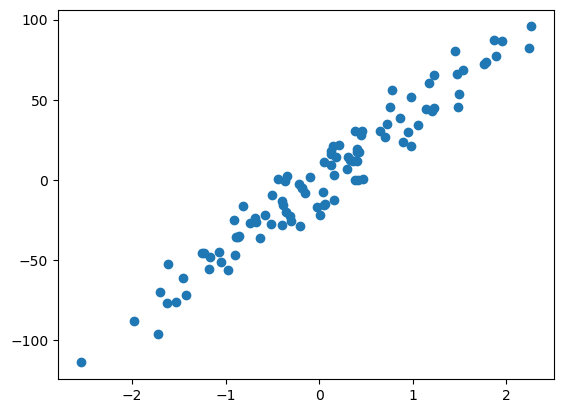

In [78]:
plt.scatter(x, y) # afficher les résultats. X en abscisse et y en ordonnée

Important: vérifier les dimensions de x et y. On remarque que y n'a pas les dimensions (100, 1). On corrige le probleme avec np.reshape

In [79]:
print(x.shape)
print(y.shape)

# redimensionner y
y = y.reshape(y.shape[0], 1)

print(y.shape)

(100, 1)
(100,)
(100, 1)


Création de la matrice X qui contient la colonne de Biais. Pour ca, on colle l'un contre l'autre le vecteur x et un vecteur 1 (avec np.ones) de dimension égale a celle de x

In [80]:
X = np.hstack((x, np.ones(x.shape)))
print(X.shape)

(100, 2)


Finalement, création d'un vecteur parametre $\theta$, initialisé avec des coefficients aléatoires. Ce vecteur est de dimension (2, 1). Si on désire toujours reproduire le meme vecteur $\theta$, on utilise comme avant np.random.seed(0).

In [81]:
np.random.seed(0) # pour produire toujours le meme vecteur theta aléatoire
theta = np.random.randn(2, 1)
theta

array([[1.76405235],
       [0.40015721]])